## Image Classification model with CNN

Convolutional Neural Networks (CNNs) are a powerful class of deep learning models, particularly effective for image classification tasks. Here's a brief overview of how they work and how i train the model in this project.


## Dataset Context
#### Content
This Data contains around 25k images of size 150x150 distributed under 6 categories.
{'buildings' -> 0,
'forest' -> 1,
'glacier' -> 2,
'mountain' -> 3,
'sea' -> 4,
'street' -> 5 }

The Train, Test and Prediction data is separated in each zip files. There are around 14k images in Train, 3k in Test and 7k in Prediction.

In this notebook will use convolutional neural network to clssifier the 6 categories nature images

**Load python libraies**

In [1]:
import warnings
warnings.simplefilter('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from tensorflow import keras
from PIL import Image
import cv2
from sklearn.utils import shuffle
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from sklearn.model_selection import train_test_split

from tqdm import tqdm

# Set the directory of the images and label the data for traing purpose

In [2]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import tensorflow as tf 
from tensorflow import keras
from keras import layers, regularizers

# Hyperparameter
img_path_train = '/kaggle/input/intel-image-classification/seg_train/seg_train'
img_path_test = '/kaggle/input/intel-image-classification/seg_test/seg_test'

# label of images
classes = os.listdir(img_path_train)
print("Classes: ",classes)



Classes:  ['mountain', 'street', 'buildings', 'sea', 'forest', 'glacier']


**Create a dataframe**

In [3]:
import pandas as pd

# Create the test dataframe
df_test = pd.DataFrame(
    {
        'filepath_test': img_path_test,
        'label_test': classes
    }
)

# Create the train dataframe
df_train = pd.DataFrame(
    {
        'filepath_train': img_path_train,
        'label_train': classes
    }
)


In [4]:
df_train.sample(4)

,filepath_train,label_train
0,/kaggle/input/intel-image-classification/seg_t...,mountain
1,/kaggle/input/intel-image-classification/seg_t...,street
3,/kaggle/input/intel-image-classification/seg_t...,sea
5,/kaggle/input/intel-image-classification/seg_t...,glacier


# Count the total images per classes

In [5]:
for cls in classes:
    print(f"{cls}: {len(os.listdir(os.path.join(img_path_train, cls)))} images")  
total = sum(len(os.listdir(os.path.join(img_path_train, cls))) for cls in classes)
print(f"Total images are {total}")

mountain: 2512 images
street: 2382 images
buildings: 2191 images
sea: 2274 images
forest: 2271 images
glacier: 2404 images
Total images are 14034


**Visualize the images from the traing directory**

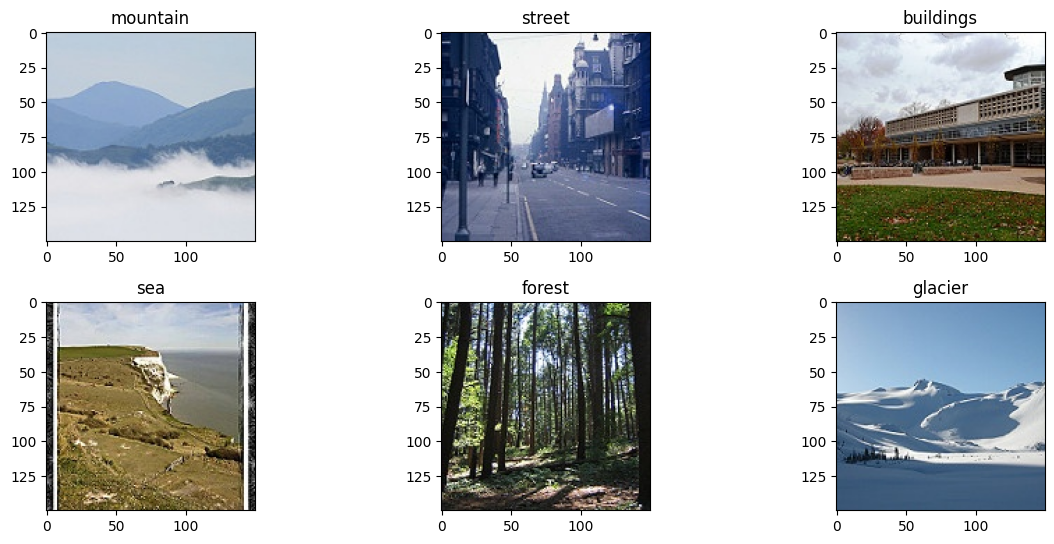

In [6]:
import matplotlib.pyplot as plt
import os
from PIL import Image

plt.figure(figsize=(12,8))
for i, cls in enumerate(classes):
    cls_path = os.path.join(img_path_train, cls)
    img_path = os.path.join(cls_path, os.listdir(cls_path)[0])
    img = Image.open(img_path)
    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(cls)

plt.tight_layout()
plt.show()


**Set image size and the bacth size**

In [7]:
img_size = (200,200)
batch_size = 32
epochs = 20

train_datagen = ImageDataGenerator(
    rescale = 1./255
        )

test_datagen = ImageDataGenerator(
    rescale = 1./255
)

**Set the data for training and testing**

In [8]:
train_generator = train_datagen.flow_from_directory(
    img_path_train,
    target_size = img_size,
    batch_size = batch_size,
    class_mode = 'categorical',
    shuffle=True,
)

validation_generator = test_datagen.flow_from_directory(
    img_path_test,
    target_size = img_size,
    batch_size = batch_size,
    class_mode = 'categorical',
    shuffle=False
    
)

test_generator = test_datagen.flow_from_directory(
    img_path_test,
    target_size = img_size,
    batch_size = batch_size,
    class_mode = 'categorical',
    shuffle=False,
)

Found 14034 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


Inspecting the shape of image and label batches from the training generator

**Visualizing a batch of training images**

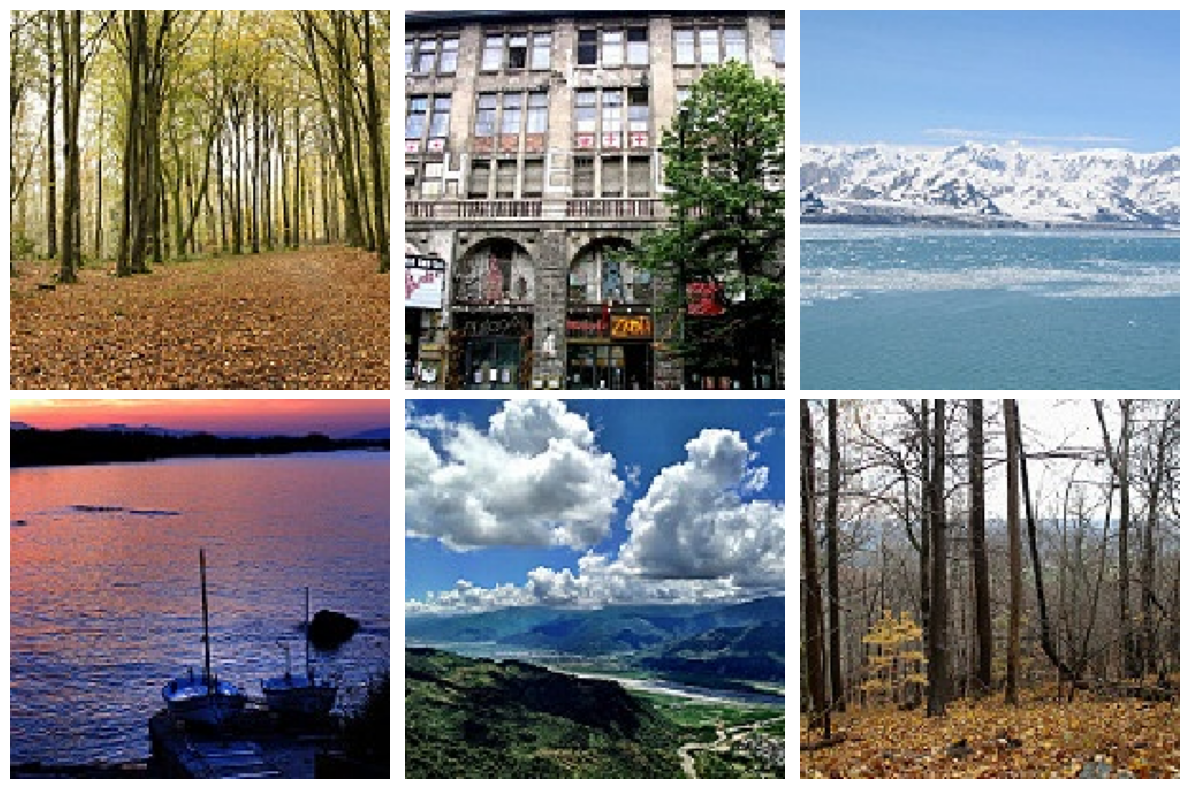

In [9]:
x_batch , y_batch = next(train_generator)

plt.figure(figsize=(12,8))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(x_batch[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

**Create a Convolutional neural network model**

In [10]:

# Let's build a CNN using Keras' Sequential capabilities
from keras.models import Sequential
from keras.layers import Conv2D, Activation, MaxPooling2D, Dropout, Flatten, Dense

model = Sequential([
    Conv2D(64, kernel_size= (3,3),padding='same', activation='relu', input_shape=(200,200,3)),
    Conv2D(64, kernel_size= (3,3),padding='same', activation='relu'),
   
    MaxPooling2D((2,2)),

    Conv2D(128, kernel_size= (3,3),padding='same', activation='relu'),
    Conv2D(128, kernel_size= (3,3),padding='same', activation='relu'),
   
    MaxPooling2D((2,2)),


    Conv2D(128, kernel_size= (3,3),padding='same', activation='relu'),
    Conv2D(128, kernel_size= (3,3),padding='same', activation='relu'),
   
    MaxPooling2D((2,2)),

    Conv2D(256, kernel_size= (3,3),padding='same', activation='relu'),
    Conv2D(256, kernel_size= (3,3),padding='same', activation='relu'),
    
    MaxPooling2D((2,2)),

    Conv2D(512, kernel_size= (3,3),padding='same', activation='relu'),
    Conv2D(512, kernel_size= (3,3),padding='same', activation='relu'),
  
    MaxPooling2D((2,2)),

    Conv2D(512, kernel_size= (3,3),padding='same', activation='relu'),
    Conv2D(512, kernel_size= (3,3),padding='same', activation='relu'),
  
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(256, activation='relu'),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(6, activation='softmax') ])


In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 200, 200, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 200, 200, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 100, 100, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 100, 100, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 100, 100, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 50, 50, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 50, 50, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 50, 50, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 25, 25, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 25, 25, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 25, 25, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 12, 12, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 12, 12, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 12, 12, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 6, 6, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 6, 6, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 6, 6, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 3, 3, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 4608)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       1,179,904 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 10,896,902 (41.57 MB)

 Trainable params: 10,896,902 (41.57 MB)

 Non-trainable params: 0 (0.00 B)

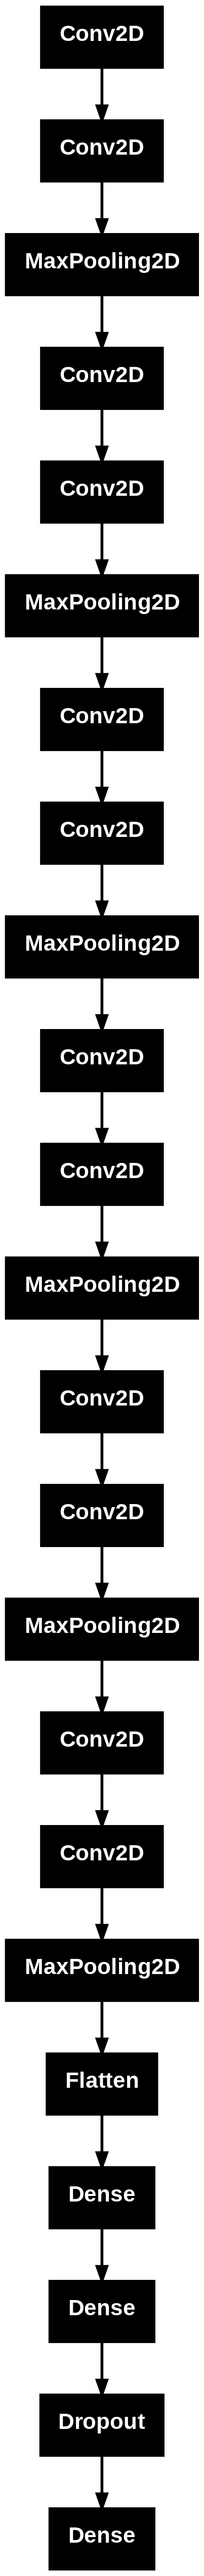

In [12]:
from keras.utils import plot_model
plot_model(model)

In [13]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor = np.sqrt(0.1),
    patience = 10,
    verbose=1
)

**Fit and train the model with RMSpro obtimizers**

In [14]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss', patience=5,restore_best_weights=True)

# initiate RMSprop optimizer
opt = keras.optimizers.RMSprop(learning_rate=0.0005)

# Let's train the model using RMSprop
model.compile(loss='categorical_crossentropy',
              optimizer=opt,
              metrics=['accuracy'])

model.fit(train_generator,
     epochs=epochs,
    validation_data=validation_generator,
        callbacks=[reduce_lr])

Epoch 1/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 177s 343ms/step - accuracy: 0.2090 - loss: 1.8006 - val_accuracy: 0.5220 - val_loss: 1.1550 - learning_rate: 5.0000e-04
Epoch 2/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 119s 270ms/step - accuracy: 0.5294 - loss: 1.1730 - val_accuracy: 0.5947 - val_loss: 1.0793 - learning_rate: 5.0000e-04
Epoch 3/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 120s 272ms/step - accuracy: 0.6401 - loss: 0.9202 - val_accuracy: 0.6757 - val_loss: 0.7900 - learning_rate: 5.0000e-04
Epoch 4/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 120s 273ms/step - accuracy: 0.7017 - loss: 0.7864 - val_accuracy: 0.6953 - val_loss: 0.8539 - learning_rate: 5.0000e-04
Epoch 5/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 120s 272ms/step - accuracy: 0.7539 - loss: 0.6754 - val_accuracy: 0.7817 - val_loss: 0.6262 - learning_rate: 5.0000e-04
Epoch 6/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 121s 274ms/step - accuracy: 0.7884 - loss: 0.5954 - val_accuracy: 0.7123 - val_loss: 0.7768 - learning_rate: 5.0000e-04
Epoch 7/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 

**Evaluate the model**

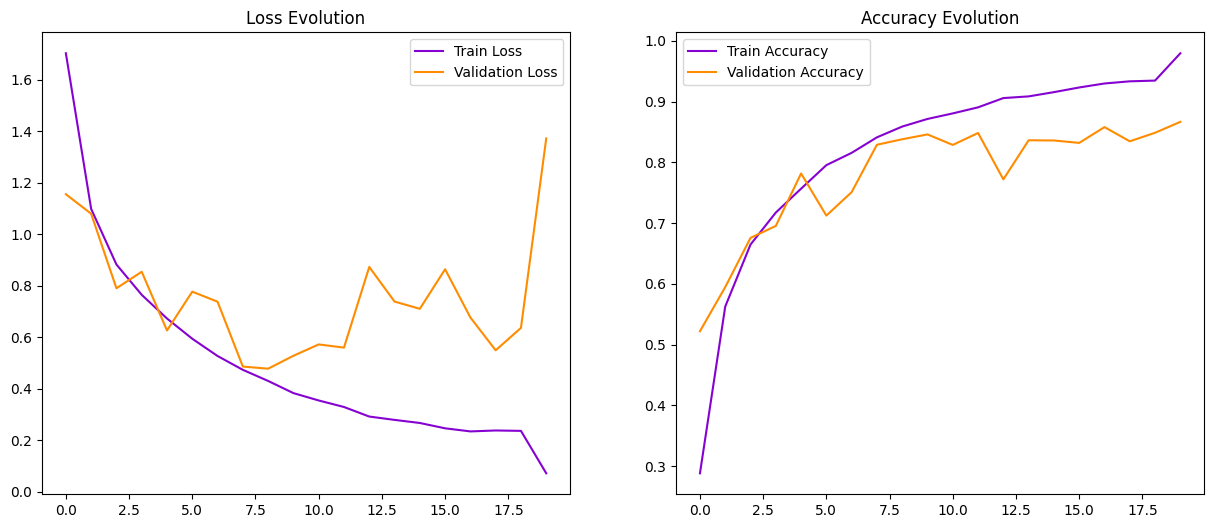

In [15]:
plt.figure(figsize=(15,6))

# Plotting the training and validation loss
plt.subplot(1, 2, 1)
plt.plot(model.history.history['loss'], label='Train Loss', color='#8502d1')
plt.plot(model.history.history['val_loss'], label='Validation Loss', color='darkorange')
plt.legend()
plt.title('Loss Evolution')

# Plotting the training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(model.history.history['accuracy'], label='Train Accuracy', color='#8502d1')
plt.plot(model.history.history['val_accuracy'], label='Validation Accuracy', color='darkorange')
plt.legend()
plt.title('Accuracy Evolution')

plt.show()

In [16]:
test_loss, test_accuracy = model.evaluate(
    test_generator,  
    steps=test_generator.samples // batch_size  
)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

93/93 ━━━━━━━━━━━━━━━━━━━━ 7s 72ms/step - accuracy: 0.8447 - loss: 1.9948
Test Loss: 1.3726931810379028
Test Accuracy: 0.8672714829444885


In [17]:
loss, accuracy = model.evaluate(train_generator)
print(f'Train accuracy: {accuracy * 100:.2f}%')

439/439 ━━━━━━━━━━━━━━━━━━━━ 39s 88ms/step - accuracy: 0.9924 - loss: 0.0271
Train accuracy: 99.39%


In [18]:
classes = {value: key for key, value in train_generator.class_indices.items()}
classes

{0: 'buildings',
 1: 'forest',
 2: 'glacier',
 3: 'mountain',
 4: 'sea',
 5: 'street'}

Evalution with Confusion matrix function 

In [19]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn import metrics
import seaborn as sns


predictions = model.predict(test_generator)
predictions = np.argmax(predictions, axis=1)



94/94 ━━━━━━━━━━━━━━━━━━━━ 8s 76ms/step


**Plot a confusion metrix to evaluate the model performance**

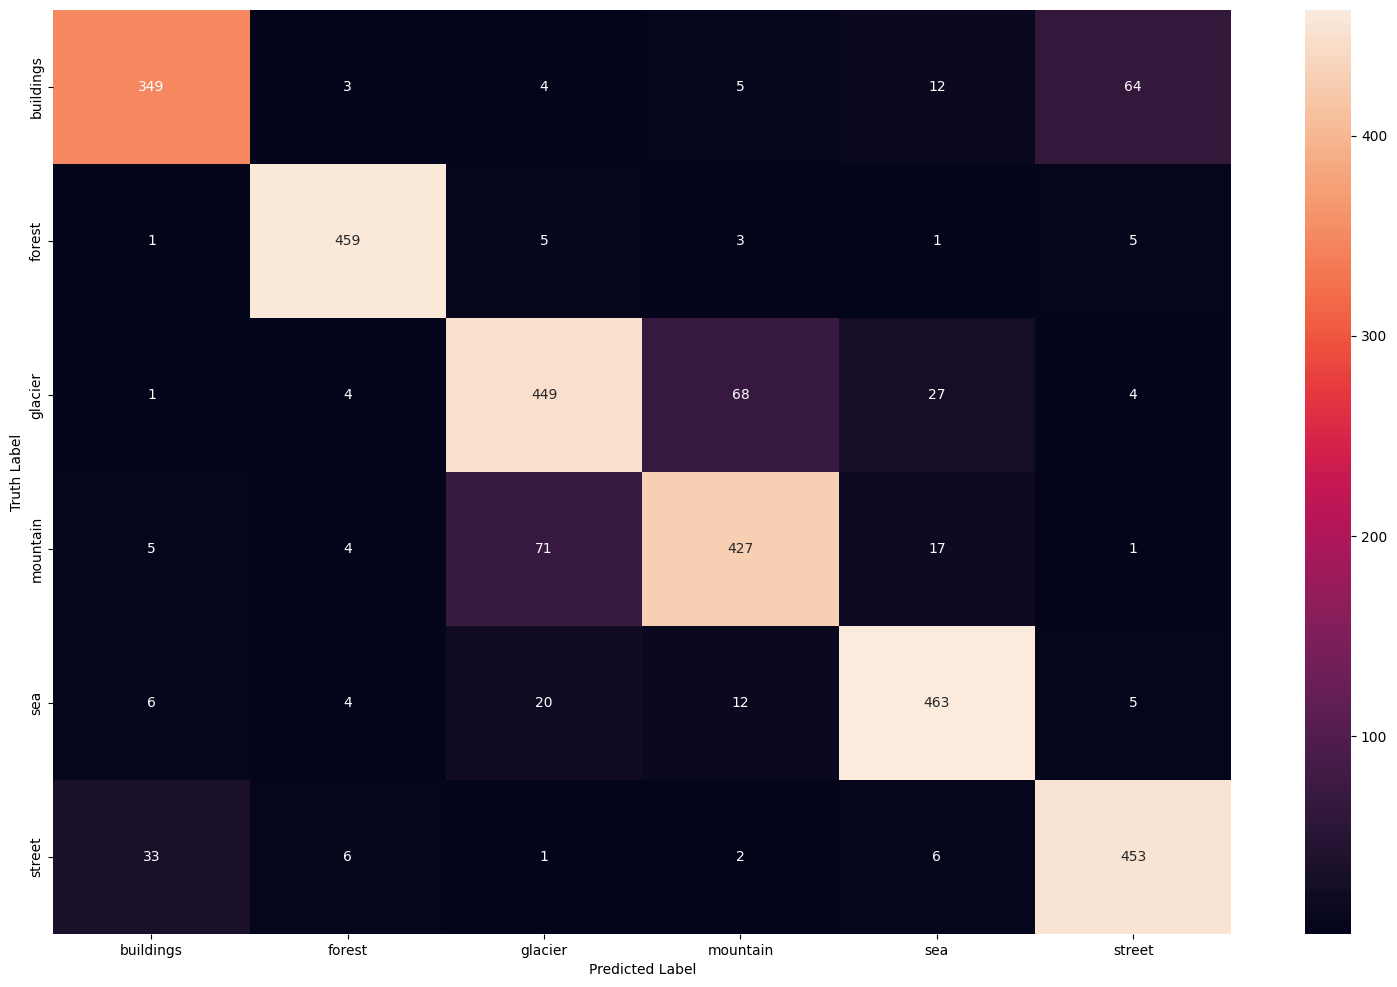

In [20]:
cm = confusion_matrix(validation_generator.classes, predictions)
labels = list(classes.keys())
plt.figure(figsize=(19,12))
sns.heatmap(cm, annot=True, fmt='d',  xticklabels=classes.values(), yticklabels=classes.values())
plt.xlabel('Predicted Label')
plt.ylabel('Truth Label')
plt.show()

### Make Prediction

In [21]:
from tensorflow.keras.preprocessing import image

def predict(img_path_train):

    
    label = list(classes.values())
    plt.figure(figsize=(12, 19))
    img = Image.open(img_path_train)
    resized_img = img.resize((224, 224))
    img = np.asarray(resized_img)
    img = np.expand_dims(img, axis=0)
    img = img / 255
    predictions = model.predict(img)
    probs = list(predictions[0])
    labels = label
    plt.subplot(2, 1, 1)
    plt.imshow(resized_img)
    plt.subplot(2, 1, 2)
    bars = plt.barh(labels, probs)
    plt.xlabel('Probability', fontsize=15)
    ax = plt.gca()
    ax.bar_label(bars, fmt = '%.2f')
    plt.show()


Print out the prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


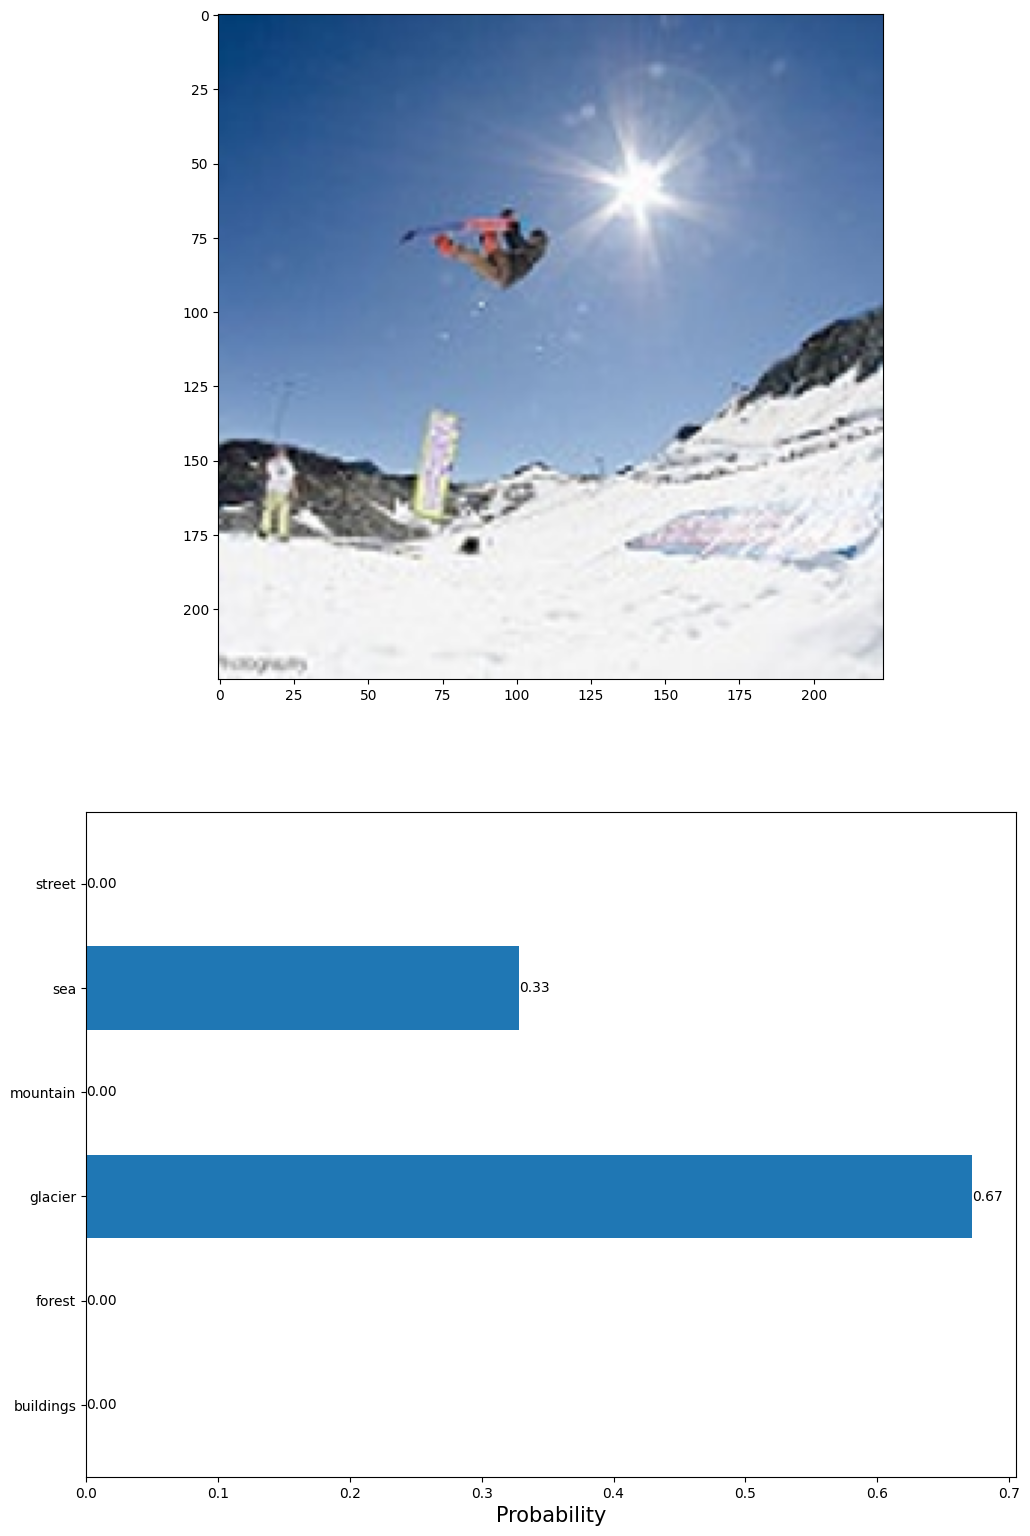

In [22]:
predict('/kaggle/input/intel-image-classification/seg_test/seg_test/glacier/20517.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


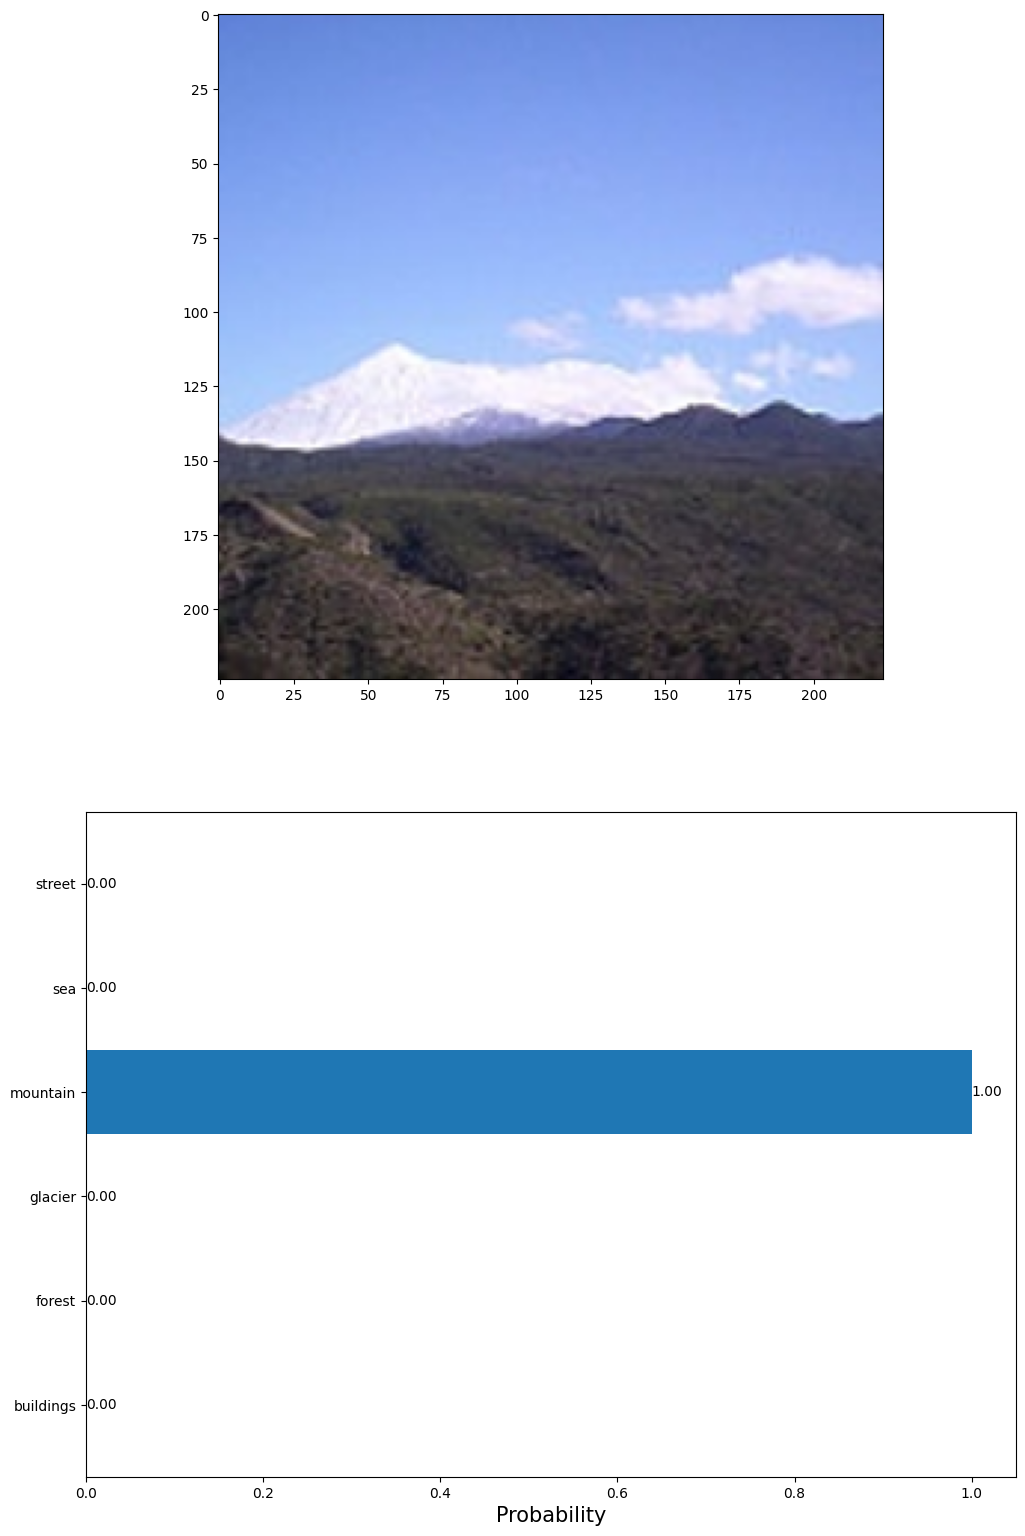

In [23]:
predict('/kaggle/input/intel-image-classification/seg_train/seg_train/mountain/15823.jpg')


**{0: 'buildings', 1: 'forest', 2: 'glacier', 3: 'mountain', 4: 'sea', 5: 'street'}**




1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


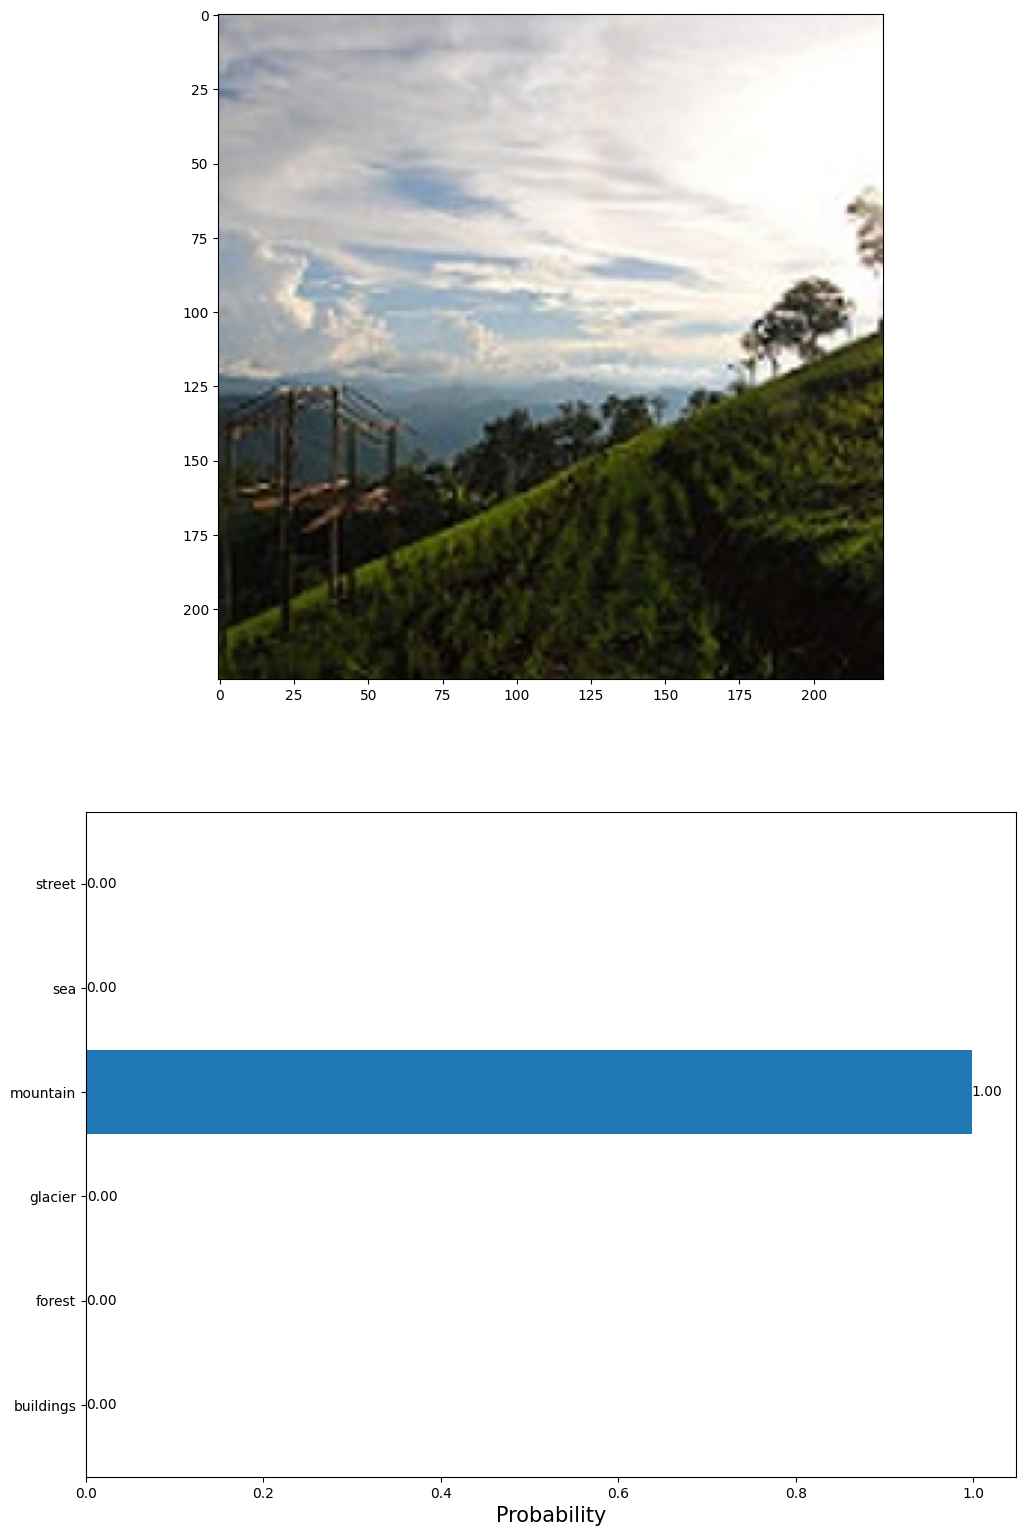

In [24]:
predict('/kaggle/input/intel-image-classification/seg_train/seg_train/mountain/4009.jpg')

### Train the Model_2 apply eaely stoping


In [25]:
model_2 = Sequential([
    Conv2D(64, kernel_size= (3,3),padding='same', activation='relu', input_shape=(200,200,3)),
    Conv2D(64, kernel_size= (3,3),padding='same', activation='relu'),
   
    MaxPooling2D((2,2)),

    Conv2D(128, kernel_size= (3,3),padding='same', activation='relu'),
    Conv2D(128, kernel_size= (3,3),padding='same', activation='relu'),
   
    MaxPooling2D((2,2)),


    Conv2D(128, kernel_size= (3,3),padding='same', activation='relu'),
    Conv2D(128, kernel_size= (3,3),padding='same', activation='relu'),
   
    MaxPooling2D((2,2)),

    Conv2D(256, kernel_size= (3,3),padding='same', activation='relu'),
    Conv2D(256, kernel_size= (3,3),padding='same', activation='relu'),
    
    MaxPooling2D((2,2)),

    Conv2D(512, kernel_size= (3,3),padding='same', activation='relu'),
    Conv2D(512, kernel_size= (3,3),padding='same', activation='relu'),
  
    MaxPooling2D((2,2)),

    Conv2D(512, kernel_size= (3,3),padding='same', activation='relu'),
    Conv2D(512, kernel_size= (3,3),padding='same', activation='relu'),
  
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(256, activation='relu'),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(6, activation='softmax') ])

model_2 = model.fit(train_generator,
     epochs=20,
    validation_data=validation_generator,
        callbacks=[early_stopping])

Epoch 1/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 121s 274ms/step - accuracy: 0.9916 - loss: 0.0307 - val_accuracy: 0.8513 - val_loss: 1.4858
Epoch 2/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 120s 272ms/step - accuracy: 0.9942 - loss: 0.0239 - val_accuracy: 0.8553 - val_loss: 1.7167
Epoch 3/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 120s 272ms/step - accuracy: 0.9938 - loss: 0.0200 - val_accuracy: 0.8533 - val_loss: 1.8007
Epoch 4/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 120s 273ms/step - accuracy: 0.9956 - loss: 0.0151 - val_accuracy: 0.8577 - val_loss: 2.1289
Epoch 5/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 120s 271ms/step - accuracy: 0.9961 - loss: 0.0144 - val_accuracy: 0.8600 - val_loss: 2.6676
Epoch 6/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 120s 273ms/step - accuracy: 0.9965 - loss: 0.0172 - val_accuracy: 0.8547 - val_loss: 2.2198


Plot the traing validation and accuracury over epoch

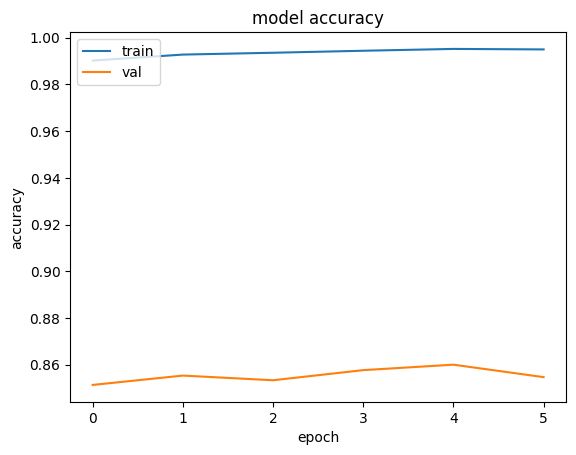

In [26]:
plt.plot(model_2.history['accuracy'])
plt.plot(model_2.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')

Plot the training and valindation loss over epoch

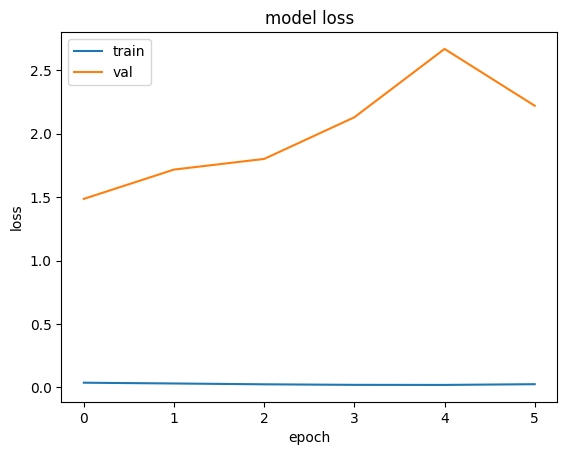

In [27]:
plt.plot(model_2.history['loss'])
plt.plot(model_2.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')

**Save the model**

In [28]:
model.save('/kaggle/working/model_2.h5')
